# LLM-as-a-Judge in Finance — Exploratory Analysis (train_api)

Exploration of `output/judge_results_train_api.jsonl`: regulatory Q&A pairs (EBA, ESMA) where each
question was answered by **2 answerer models** and each answer was scored by **3 judge models**.

Record structure:
```
{
  "question_id", "regulator", "question", "ground_truth",
  "answers": {
      "<answerer_model>": {
          "text": "<candidate answer>",
          "judge_scores": {
              "<judge_model>": {
                  "reasoning": {dim: "..."},
                  "accuracy": 1-5, "completeness": 1-5,
                  "topic_coherence": 1-5, "citation_quality": 1-5
              }, ...
          }
      }, ...
  },
  "meta": {"answerer_models", "judge_models", "status", "legal_act", "topic", "subject_matter", "url"}
}
```

Score dimensions: **accuracy**, **completeness**, **topic_coherence**, **citation_quality** (1–5 scale).
We flatten this into a long-form table with one row per (question, answerer, judge).</cell id="2dda65b7">


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

BASE = Path("../output")
DIMS = ["accuracy", "completeness", "topic_coherence", "citation_quality"]


def load_jsonl(path):
    records = []
    with open(BASE / path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def to_long_df(records):
    """One row per (question, answerer_model, judge_model)."""
    rows = []
    for rec in records:
        meta = rec.get("meta", {})
        for answerer, ans in rec.get("answers", {}).items():
            judge_scores = ans.get("judge_scores", {})
            for judge, sc in judge_scores.items():
                row = {
                    "question_id": rec["question_id"],
                    "regulator": rec["regulator"],
                    "question": rec["question"],
                    "ground_truth": rec["ground_truth"],
                    "answerer_model": answerer,
                    "candidate_answer": ans.get("text", ""),
                    "judge_model": judge,
                    "legal_act": meta.get("legal_act"),
                    "topic": meta.get("topic"),
                    "subject_matter": meta.get("subject_matter"),
                    "status": meta.get("status"),
                    "url": meta.get("url"),
                }
                for dim in DIMS:
                    row[dim] = sc.get(dim)
                row["reasoning"] = sc.get("reasoning", {})
                rows.append(row)
    df = pd.DataFrame(rows)
    for dim in DIMS:
        df[dim] = pd.to_numeric(df[dim], errors="coerce")
    df["overall"] = df[DIMS].mean(axis=1, skipna=False)  # NaN if any dim is missing
    return df


records = load_jsonl("judge_results_train_api.jsonl")
df_raw = to_long_df(records)

# Discard judgments with any missing score dimension up front, so every downstream
# average/plot is computed only over complete-case rows.
n_before = len(df_raw)
df = df_raw.dropna(subset=DIMS).reset_index(drop=True)
n_after = len(df)

ANSWERERS = sorted(df["answerer_model"].unique())
JUDGES = sorted(df["judge_model"].unique())

print(f"Source questions      : {len(records)}")
print(f"Long-form rows (raw)   : {n_before}  (questions × answerers × judges)")
print(f"Dropped (incomplete)   : {n_before - n_after}  ({(n_before - n_after) / n_before * 100:.2f}%)")
print(f"Long-form rows (clean)  : {n_after}")
print(f"Answerer models        : {ANSWERERS}")
print(f"Judge models            : {JUDGES}")
print(f"Regulators              : {sorted(df['regulator'].unique())}")
df.head()

Source questions      : 2138
Long-form rows (raw)   : 12828  (questions × answerers × judges)
Dropped (incomplete)   : 93  (0.72%)
Long-form rows (clean)  : 12735
Answerer models        : ['meta-llama/Llama-3.3-70B-Instruct', 'swiss-ai/Apertus-70B-Instruct-2509']
Judge models            : ['Qwen/Qwen3.5-27B', 'google/gemma-4-31B-it', 'zai-org/GLM-4.7-Flash']
Regulators              : ['EBA', 'ESMA']


,question_id,regulator,question,ground_truth,answerer_model,candidate_answer,judge_model,legal_act,topic,subject_matter,status,url,accuracy,completeness,topic_coherence,citation_quality,reasoning,overall
0,EBA_2015_1770,EBA,Can the list of exemption from bail-in of Arti...,"Yes, under Article 44(2)(g)(i) of Directive 20...",swiss-ai/Apertus-70B-Instruct-2509,Based on Article 44(2)(g)(i) of Directive 2014...,google/gemma-4-31B-it,Directive 2014/59/EU (BRRD),Resolution tools and powers,Bail-in tool,Final Q&A,https://www.eba.europa.eu/single-rule-book-qa/...,5.0,5.0,5.0,5.0,{'accuracy': 'The candidate correctly conclude...,5.0
1,EBA_2015_1770,EBA,Can the list of exemption from bail-in of Arti...,"Yes, under Article 44(2)(g)(i) of Directive 20...",swiss-ai/Apertus-70B-Instruct-2509,Based on Article 44(2)(g)(i) of Directive 2014...,Qwen/Qwen3.5-27B,Directive 2014/59/EU (BRRD),Resolution tools and powers,Bail-in tool,Final Q&A,https://www.eba.europa.eu/single-rule-book-qa/...,5.0,4.0,5.0,2.0,{'accuracy': 'The candidate correctly conclude...,4.0
2,EBA_2015_1770,EBA,Can the list of exemption from bail-in of Arti...,"Yes, under Article 44(2)(g)(i) of Directive 20...",swiss-ai/Apertus-70B-Instruct-2509,Based on Article 44(2)(g)(i) of Directive 2014...,zai-org/GLM-4.7-Flash,Directive 2014/59/EU (BRRD),Resolution tools and powers,Bail-in tool,Final Q&A,https://www.eba.europa.eu/single-rule-book-qa/...,5.0,5.0,5.0,5.0,{'accuracy': 'The candidate correctly affirms ...,5.0
3,EBA_2015_1770,EBA,Can the list of exemption from bail-in of Arti...,"Yes, under Article 44(2)(g)(i) of Directive 20...",meta-llama/Llama-3.3-70B-Instruct,The exemptions from bail-in under Article 44(2...,google/gemma-4-31B-it,Directive 2014/59/EU (BRRD),Resolution tools and powers,Bail-in tool,Final Q&A,https://www.eba.europa.eu/single-rule-book-qa/...,5.0,5.0,5.0,5.0,{'accuracy': 'The candidate correctly conclude...,5.0
4,EBA_2015_1770,EBA,Can the list of exemption from bail-in of Arti...,"Yes, under Article 44(2)(g)(i) of Directive 20...",meta-llama/Llama-3.3-70B-Instruct,The exemptions from bail-in under Article 44(2...,Qwen/Qwen3.5-27B,Directive 2014/59/EU (BRRD),Resolution tools and powers,Bail-in tool,Final Q&A,https://www.eba.europa.eu/single-rule-book-qa/...,5.0,4.0,5.0,4.0,{'accuracy': 'The candidate correctly conclude...,4.5


## 1 · Dataset Overview

In [2]:
# Records and regulator split
print("=== Questions per regulator ===")
print(df.drop_duplicates("question_id")["regulator"].value_counts())
print()

print("=== Judgments per (answerer, judge) pair ===")
print(df.groupby(["answerer_model", "judge_model"]).size().unstack())
print()

# Overall summary: missingness and mean score per judge × answerer
summary = (
    df.groupby(["judge_model", "answerer_model"])
      .agg(n=("overall", "size"),
           n_valid=("overall", lambda s: s.notna().sum()),
           mean_overall=("overall", "mean"))
)
summary["missing_pct"] = (1 - summary["n_valid"] / summary["n"]) * 100
summary.round(2)

=== Questions per regulator ===
regulator
EBA     1868
ESMA     270
Name: count, dtype: int64

=== Judgments per (answerer, judge) pair ===
judge_model                         Qwen/Qwen3.5-27B  google/gemma-4-31B-it  \
answerer_model                                                                
meta-llama/Llama-3.3-70B-Instruct               2138                   2138   
swiss-ai/Apertus-70B-Instruct-2509              2138                   2138   

judge_model                         zai-org/GLM-4.7-Flash  
answerer_model                                             
meta-llama/Llama-3.3-70B-Instruct                    2099  
swiss-ai/Apertus-70B-Instruct-2509                   2084  



n  n_valid  \
judge_model           answerer_model                                      
Qwen/Qwen3.5-27B      meta-llama/Llama-3.3-70B-Instruct   2138     2138   
                      swiss-ai/Apertus-70B-Instruct-2509  2138     2138   
google/gemma-4-31B-it meta-llama/Llama-3.3-70B-Instruct   2138     2138   
                      swiss-ai/Apertus-70B-Instruct-2509  2138     2138   
zai-org/GLM-4.7-Flash meta-llama/Llama-3.3-70B-Instruct   2099     2099   
                      swiss-ai/Apertus-70B-Instruct-2509  2084     2084   

                                                          mean_overall  \
judge_model           answerer_model                                     
Qwen/Qwen3.5-27B      meta-llama/Llama-3.3-70B-Instruct           2.82   
                      swiss-ai/Apertus-70B-Instruct-2509          2.59   
google/gemma-4-31B-it meta-llama/Llama-3.3-70B-Instruct           3.24   
                      swiss-ai/Apertus-70B-Instruct-2509          2.94   
zai-org/GLM-4.7-Flash meta-llama/Llama-3.3-70B-Instruct           3.32   
                      swiss-ai/Apertus-70B-Instruct-2509          3.00   

                                                          missing_pct  
judge_model           answerer_model                                   
Qwen/Qwen3.5-27B      meta-llama/Llama-3.3-70B-Instruct           0.0  
                      swiss-ai/Apertus-70B-Instruct-2509          0.0  
google/gemma-4-31B-it meta-llama/Llama-3.3-70B-Instruct           0.0  
                      swiss-ai/Apertus-70B-Instruct-2509          0.0  
zai-org/GLM-4.7-Flash meta-llama/Llama-3.3-70B-Instruct           0.0  
                      swiss-ai/Apertus-70B-Instruct-2509          0.0

## 2 · Score Distributions

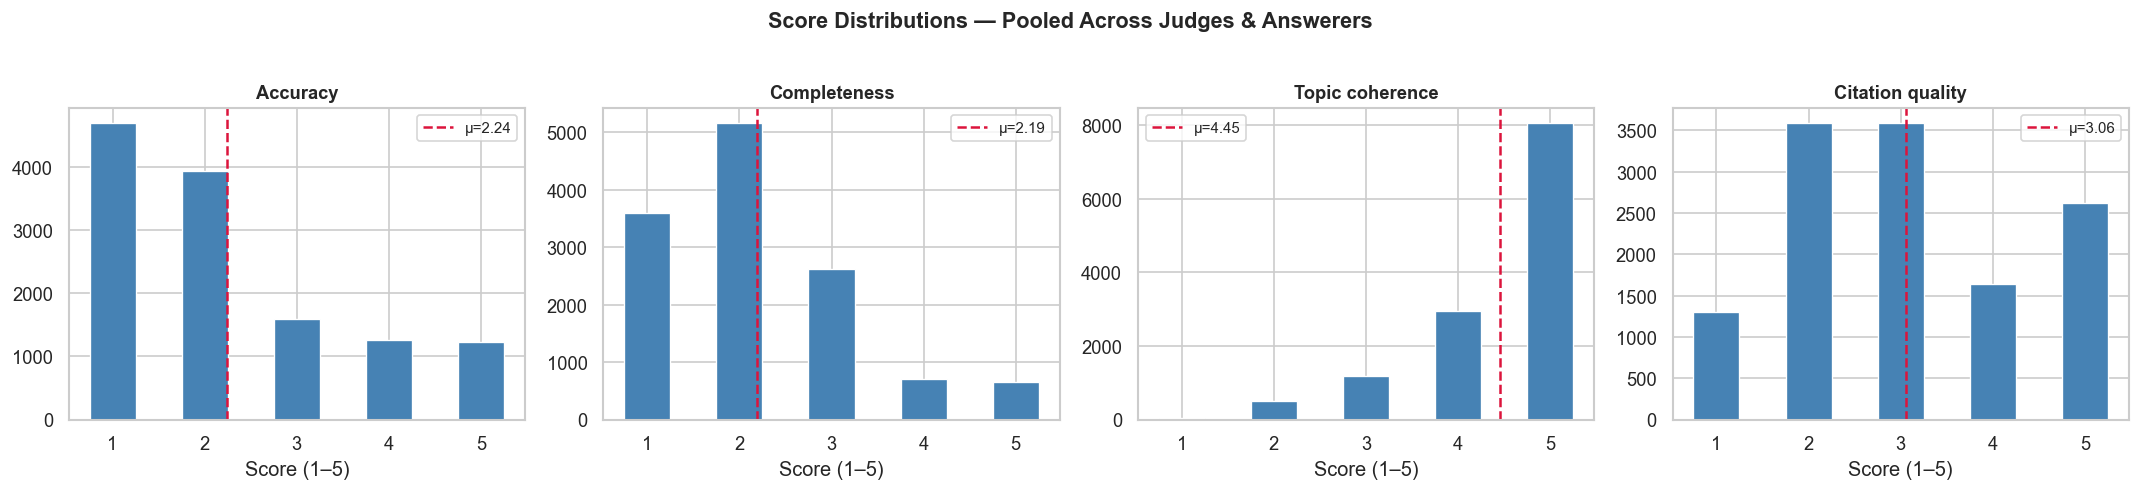

In [3]:
# Distribution of each dimension, all judgments pooled
fig, axes = plt.subplots(1, len(DIMS), figsize=(18, 4))
bins = np.arange(0.75, 5.51, 0.5)

for ax, dim in zip(axes, DIMS):
    data = df[dim].dropna()
    ax.hist(data, bins=bins, color="steelblue", edgecolor="white", linewidth=0.8)
    ax.axvline(data.mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"μ={data.mean():.2f}")
    ax.set_title(dim.replace("_", " ").capitalize(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Score (1–5)")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=9)

plt.suptitle("Score Distributions — Pooled Across Judges & Answerers", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

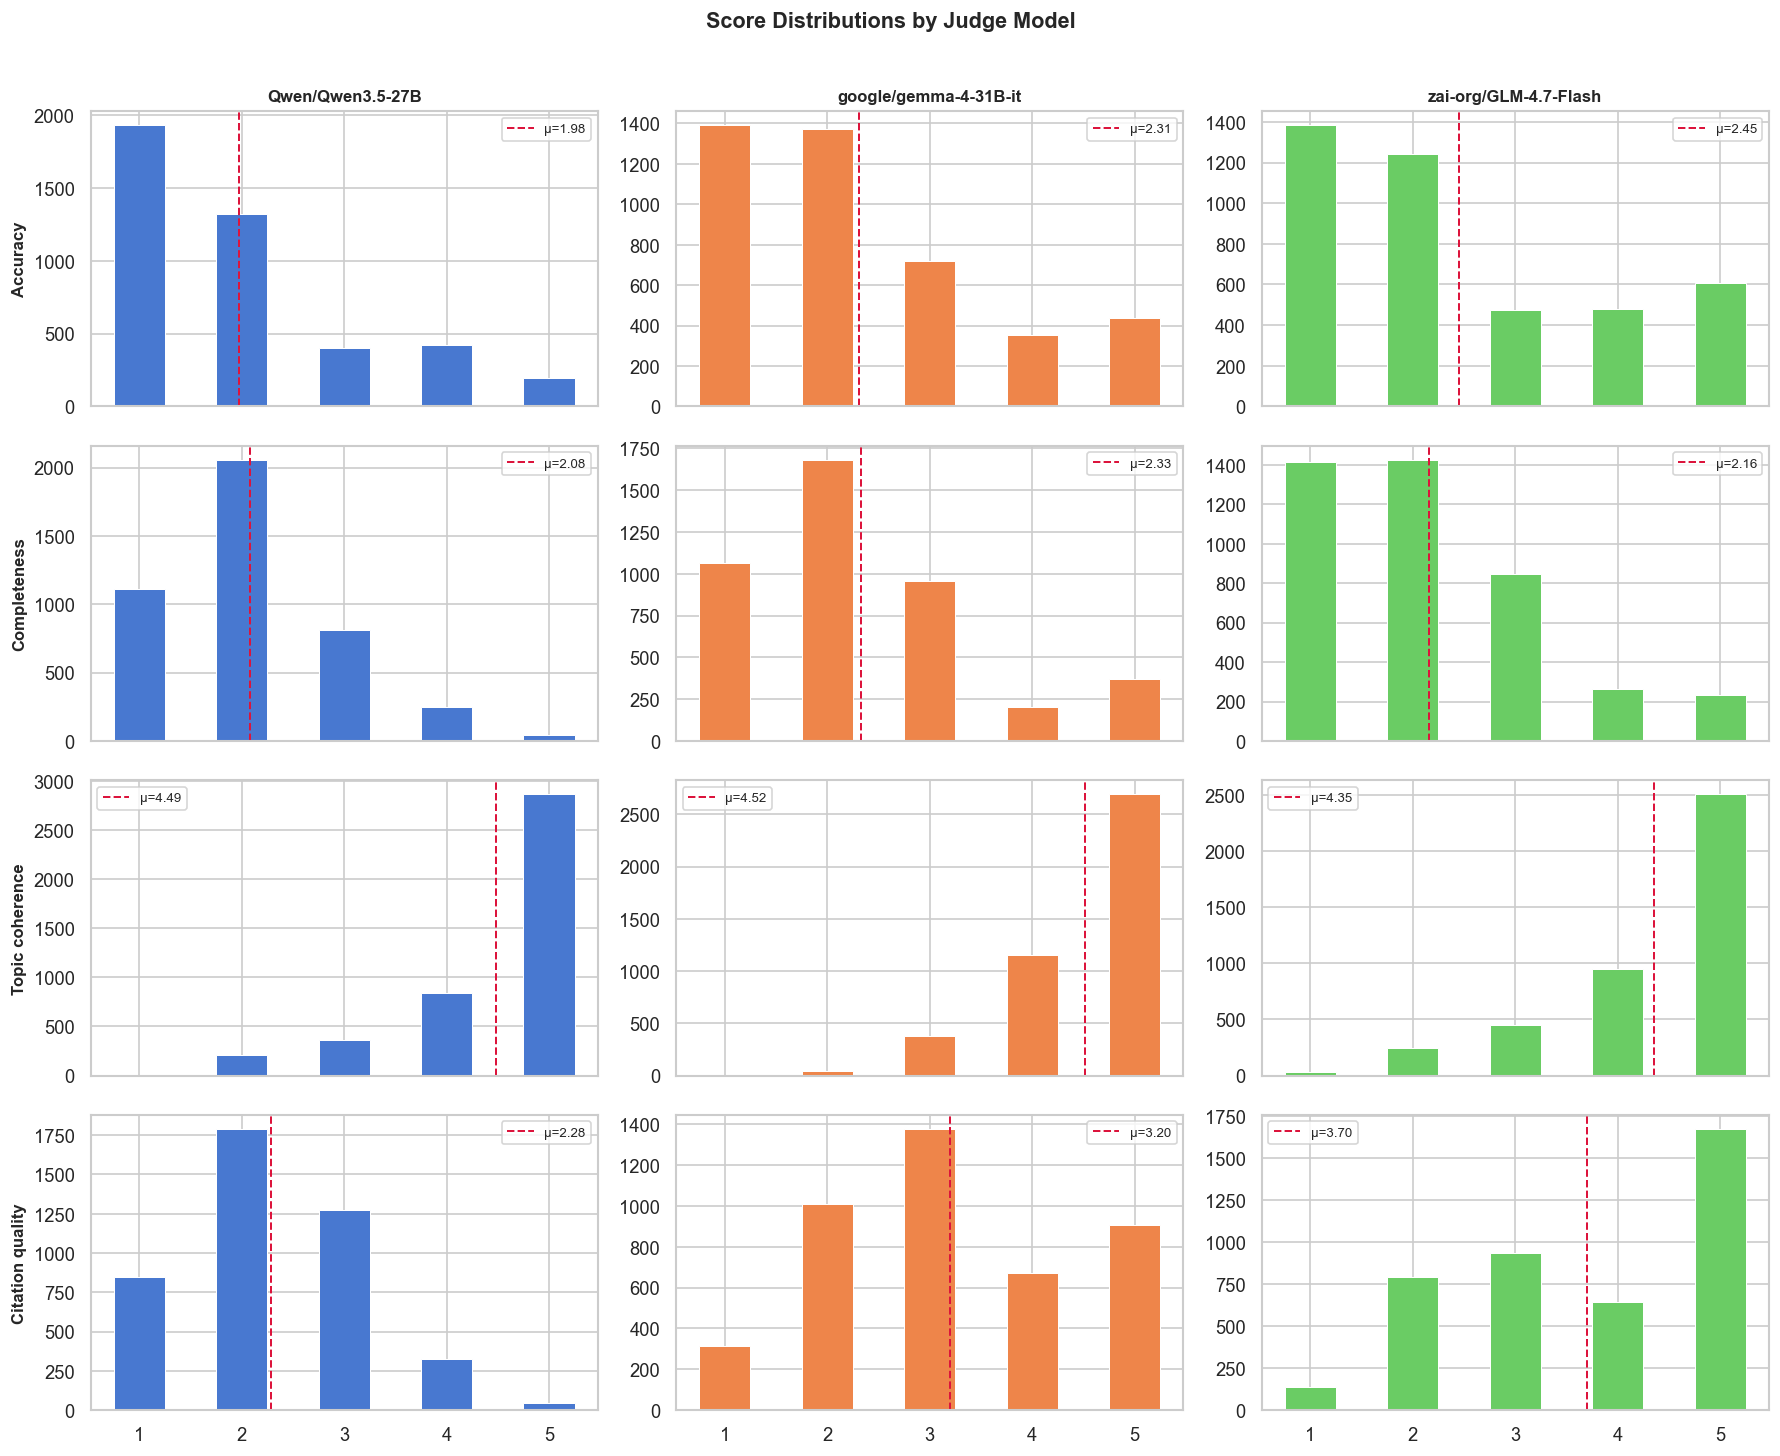

In [4]:
# Each dimension, faceted by judge model — reveals per-judge scoring tendencies
fig, axes = plt.subplots(len(DIMS), len(JUDGES), figsize=(5 * len(JUDGES), 3 * len(DIMS)), sharex="col")
colors = sns.color_palette("muted", len(JUDGES))

for row, dim in enumerate(DIMS):
    for col, judge in enumerate(JUDGES):
        ax = axes[row][col]
        data = df.loc[df["judge_model"] == judge, dim].dropna()
        ax.hist(data, bins=bins, color=colors[col], edgecolor="white", linewidth=0.6)
        ax.axvline(data.mean(), color="crimson", linestyle="--", linewidth=1.2, label=f"μ={data.mean():.2f}")
        ax.legend(fontsize=8)
        ax.set_xticks([1, 2, 3, 4, 5])
        if row == 0:
            ax.set_title(judge, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(dim.replace("_", " ").capitalize(), fontsize=10, fontweight="bold")

plt.suptitle("Score Distributions by Judge Model", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3 · Answerer Model Comparison

Compares the two answerer models (`swiss-ai/Apertus-70B-Instruct-2509` vs `meta-llama/Llama-3.3-70B-Instruct`),
averaging each judge's score per question.

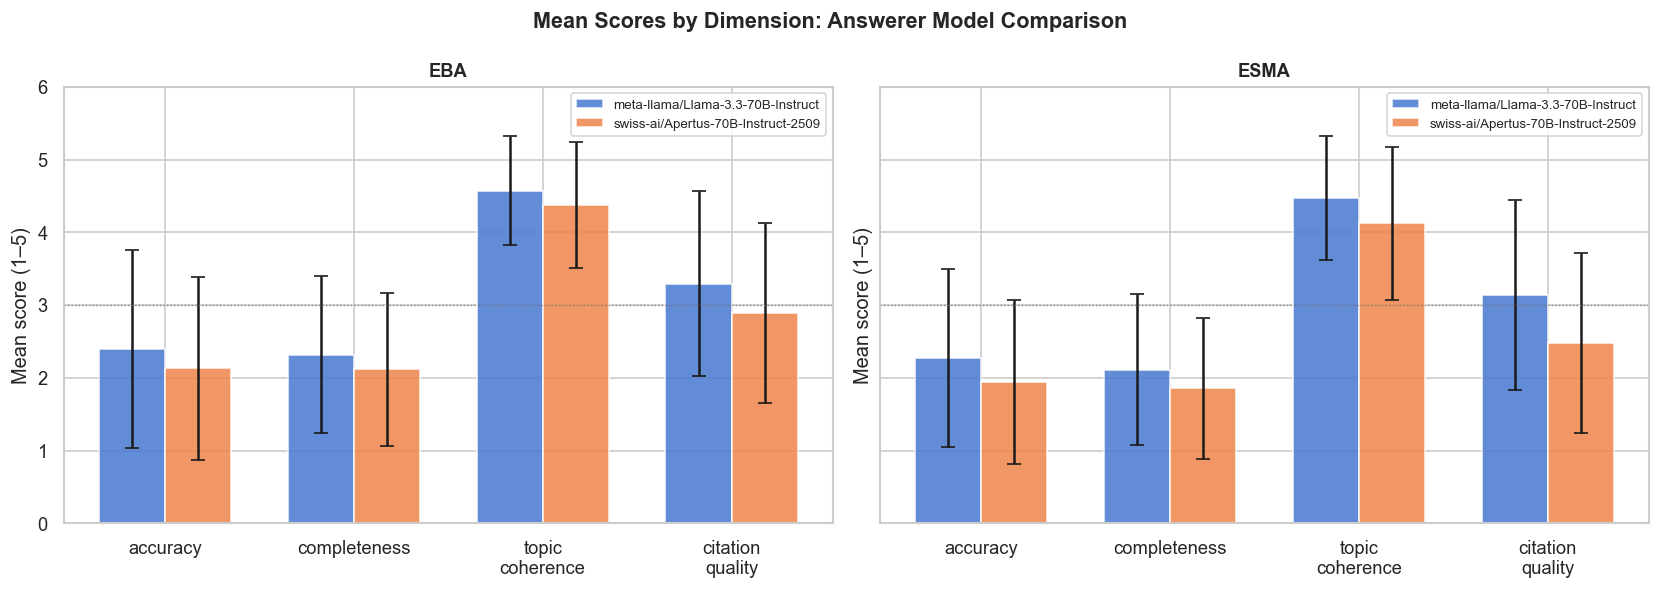

answerer_model              meta-llama/Llama-3.3-70B-Instruct  \
regulator dimension                                             
EBA       accuracy                                       2.40   
          citation_quality                               3.29   
          completeness                                   2.32   
          topic_coherence                                4.57   
ESMA      accuracy                                       2.27   
          citation_quality                               3.14   
          completeness                                   2.11   
          topic_coherence                                4.47   

answerer_model              swiss-ai/Apertus-70B-Instruct-2509  
regulator dimension                                             
EBA       accuracy                                        2.13  
          citation_quality                                2.89  
          completeness                                    2.12  
          topic_coherence                                 4.38  
ESMA      accuracy                                        1.94  
          citation_quality                                2.48  
          completeness                                    1.86  
          topic_coherence                                 4.12

In [5]:
# Mean ± std per dimension, by answerer model and regulator
records_ = []
for (answerer, regulator), sub in df.groupby(["answerer_model", "regulator"]):
    for dim in DIMS:
        records_.append({
            "answerer_model": answerer, "regulator": regulator, "dimension": dim,
            "mean": sub[dim].mean(), "std": sub[dim].std(), "n": sub[dim].notna().sum(),
        })
ans_stats = pd.DataFrame(records_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(DIMS))
width = 0.35

for ax, regulator in zip(axes, sorted(df["regulator"].unique())):
    sub = ans_stats[ans_stats["regulator"] == regulator]
    for i, answerer in enumerate(ANSWERERS):
        t = sub[sub["answerer_model"] == answerer].set_index("dimension").reindex(DIMS)
        ax.bar(x + (i - 0.5) * width, t["mean"], width, yerr=t["std"], capsize=4,
               alpha=0.85, label=answerer)
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace("_", "\n") for d in DIMS])
    ax.set_ylim(0, 6)
    ax.set_ylabel("Mean score (1–5)")
    ax.set_title(regulator, fontsize=11, fontweight="bold")
    ax.axhline(3, color="grey", linestyle=":", linewidth=0.8)
    ax.legend(fontsize=8)

plt.suptitle("Mean Scores by Dimension: Answerer Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

ans_stats.pivot_table(index=["regulator", "dimension"], columns="answerer_model", values="mean").round(2)

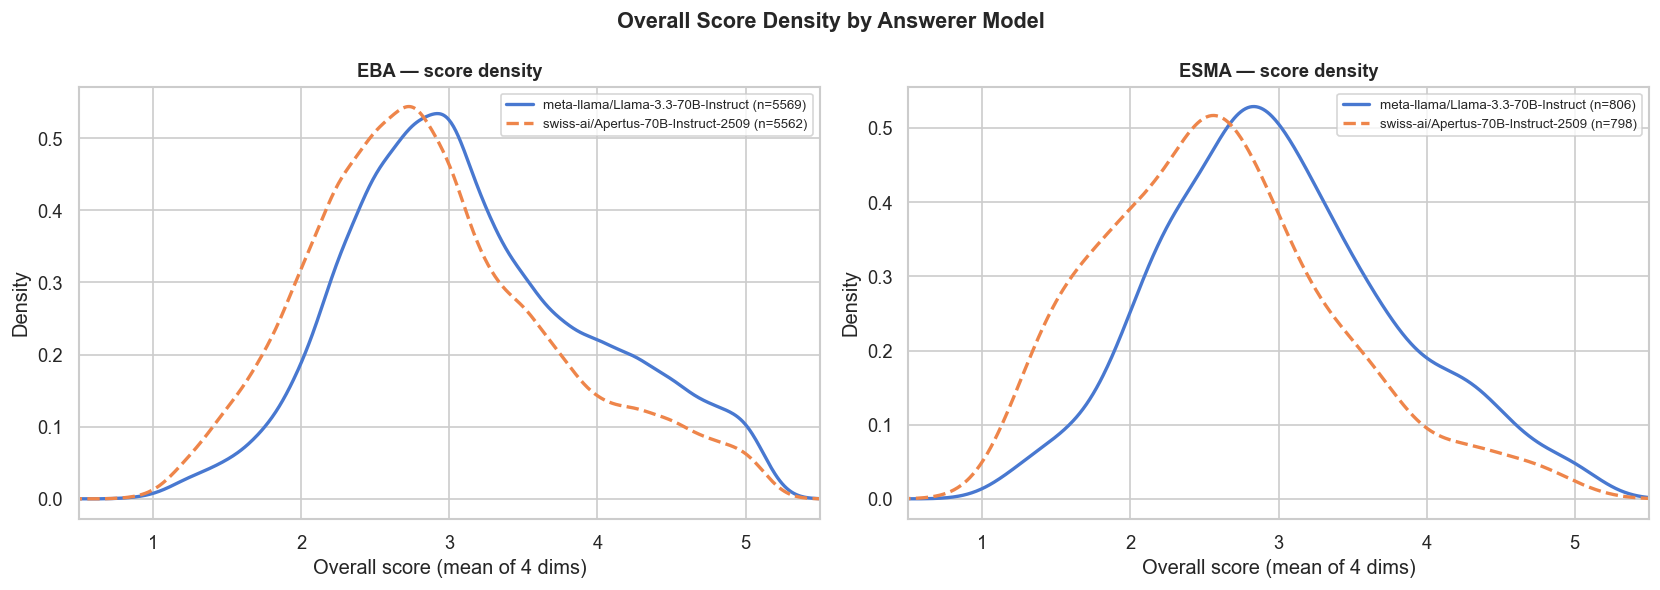

In [6]:
# KDE overlay: overall score density per answerer model, per regulator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, regulator in zip(axes, sorted(df["regulator"].unique())):
    for answerer, ls in zip(ANSWERERS, ["-", "--"]):
        data = df.loc[(df["regulator"] == regulator) & (df["answerer_model"] == answerer), "overall"].dropna()
        data.plot.kde(ax=ax, label=f"{answerer} (n={len(data)})", linestyle=ls, linewidth=2)
    ax.set_xlim(0.5, 5.5)
    ax.set_xlabel("Overall score (mean of 4 dims)")
    ax.set_title(f"{regulator} — score density", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Overall Score Density by Answerer Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · Judge Comparison & Inter-judge Agreement

Three judges (`google/gemma-4-31B-it`, `Qwen/Qwen3.5-27B`, `zai-org/GLM-4.7-Flash`) scored the same
answers — this lets us measure judge leniency/strictness and pairwise agreement directly, without
needing a small/big model split.

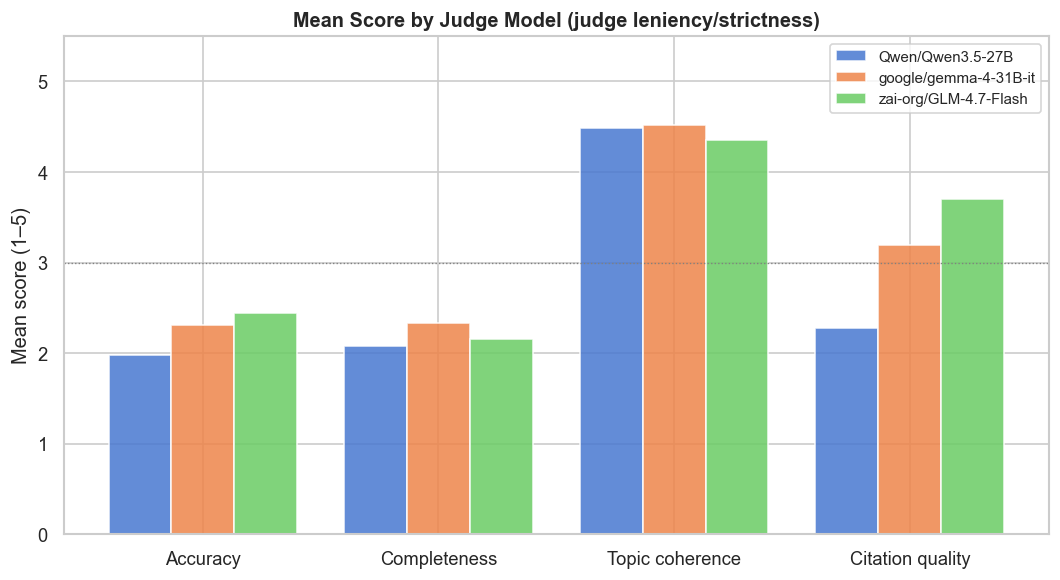

,accuracy,completeness,topic_coherence,citation_quality
judge_model,,,,
Qwen/Qwen3.5-27B,1.98,2.08,4.49,2.28
google/gemma-4-31B-it,2.31,2.33,4.52,3.20
zai-org/GLM-4.7-Flash,2.45,2.16,4.35,3.70


In [7]:
# Mean score per judge, per dimension — reveals leniency/strictness bias
judge_means = df.groupby("judge_model")[DIMS].mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(DIMS))
width = 0.8 / len(JUDGES)

for i, judge in enumerate(JUDGES):
    ax.bar(x + (i - (len(JUDGES) - 1) / 2) * width, judge_means.loc[judge], width,
           label=judge, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([d.replace("_", " ").capitalize() for d in DIMS])
ax.set_ylabel("Mean score (1–5)")
ax.set_ylim(0, 5.5)
ax.axhline(3, color="grey", linestyle=":", linewidth=0.8)
ax.set_title("Mean Score by Judge Model (judge leniency/strictness)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

judge_means.round(2)

In [8]:
from itertools import combinations
from sklearn.metrics import cohen_kappa_score


def krippendorff_alpha_interval(y1, y2):
    """Krippendorff's alpha, interval metric d²(k,l)=(k-l)², for two raters."""
    y1, y2 = np.asarray(y1, float), np.asarray(y2, float)
    D_o = np.mean((y1 - y2) ** 2)
    all_v = np.concatenate([y1, y2])
    N = len(all_v)
    D_e = (2 * N * np.sum(all_v ** 2) - 2 * np.sum(all_v) ** 2) / (N * (N - 1))
    return np.nan if D_e == 0 else 1.0 - D_o / D_e


agree_rows = []
for dim in DIMS:
    wide = df.pivot_table(index=["question_id", "answerer_model"], columns="judge_model", values=dim)
    for j1, j2 in combinations(JUDGES, 2):
        sub = wide[[j1, j2]].dropna()
        y1 = np.clip(sub[j1].round(), 1, 5).astype(int).values
        y2 = np.clip(sub[j2].round(), 1, 5).astype(int).values
        agree_rows.append({
            "dimension": dim, "judge_pair": f"{j1} vs {j2}", "n_pairs": len(sub),
            "kappa_linear": cohen_kappa_score(y1, y2, labels=[1, 2, 3, 4, 5], weights="linear"),
            "kappa_quadratic": cohen_kappa_score(y1, y2, labels=[1, 2, 3, 4, 5], weights="quadratic"),
            "krippendorff_alpha": krippendorff_alpha_interval(y1, y2),
        })

agree_df = pd.DataFrame(agree_rows)
agree_df.set_index(["dimension", "judge_pair"]).round(3)

n_pairs  \
dimension        judge_pair                                                
accuracy         Qwen/Qwen3.5-27B vs google/gemma-4-31B-it          4276   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash          4183   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash     4183   
completeness     Qwen/Qwen3.5-27B vs google/gemma-4-31B-it          4276   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash          4183   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash     4183   
topic_coherence  Qwen/Qwen3.5-27B vs google/gemma-4-31B-it          4276   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash          4183   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash     4183   
citation_quality Qwen/Qwen3.5-27B vs google/gemma-4-31B-it          4276   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash          4183   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash     4183   

                                                                 kappa_linear  \
dimension        judge_pair                                                     
accuracy         Qwen/Qwen3.5-27B vs google/gemma-4-31B-it              0.648   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash              0.548   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash         0.596   
completeness     Qwen/Qwen3.5-27B vs google/gemma-4-31B-it              0.631   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash              0.547   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash         0.552   
topic_coherence  Qwen/Qwen3.5-27B vs google/gemma-4-31B-it              0.426   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash              0.341   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash         0.305   
citation_quality Qwen/Qwen3.5-27B vs google/gemma-4-31B-it              0.277   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash              0.130   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash         0.327   

                                                                 kappa_quadratic  \
dimension        judge_pair                                                        
accuracy         Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                 0.785   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                 0.692   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash            0.738   
completeness     Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                 0.740   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                 0.696   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash            0.704   
topic_coherence  Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                 0.559   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                 0.458   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash            0.405   
citation_quality Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                 0.432   
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                 0.239   
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash            0.435   

                                                                 krippendorff_alpha  
dimension        judge_pair                                                          
accuracy         Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                    0.781  
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                    0.682  
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash               0.738  
completeness     Qwen/Qwen3.5-27B vs google/gemma-4-31B-it                    0.737  
                 Qwen/Qwen3.5-27B vs zai-org/GLM-4.7-Flash                    0.695  
                 google/gemma-4-31B-it vs zai-org/GLM-4.7-Flash               0.703  


/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_29165/417058892.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


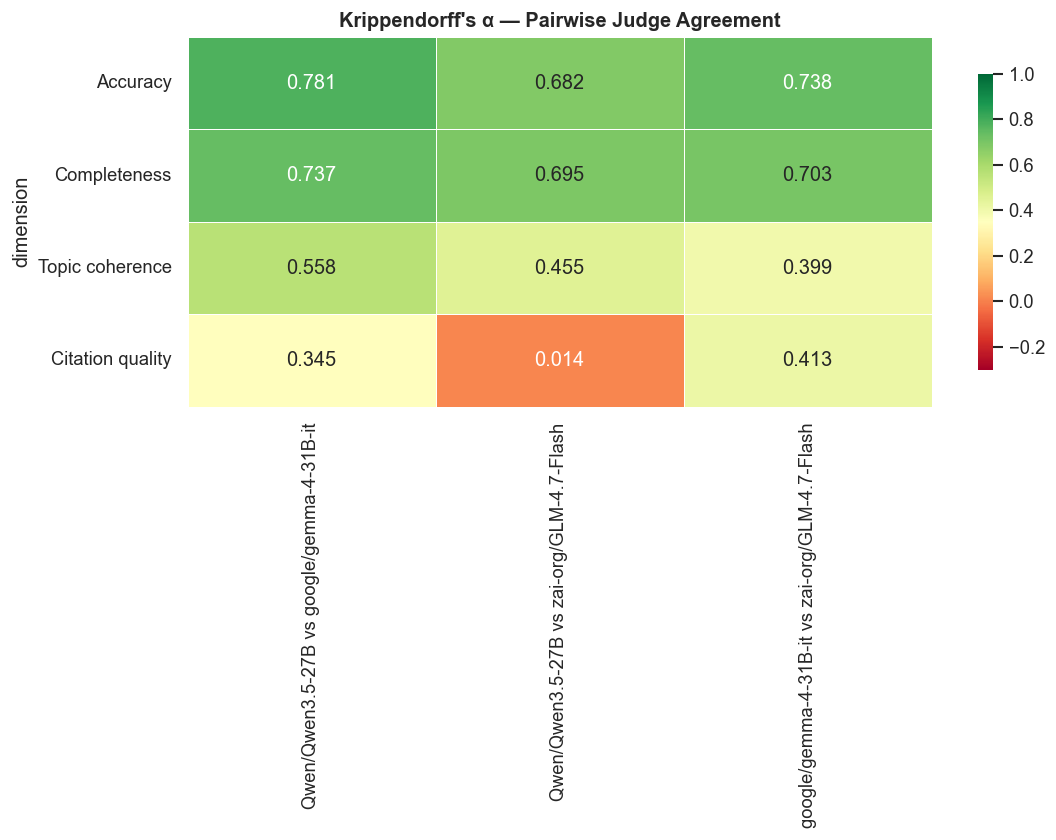

In [9]:
# Heatmap: Krippendorff alpha, rows = dimension, cols = judge pair
pivot_alpha = agree_df.pivot(index="dimension", columns="judge_pair", values="krippendorff_alpha").reindex(DIMS)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_alpha, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-0.3, vmax=1.0,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Krippendorff's α — Pairwise Judge Agreement", fontsize=12, fontweight="bold")
ax.set_yticklabels([d.replace("_", " ").capitalize() for d in DIMS], rotation=0)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5 · EBA vs ESMA Comparison

/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_29165/2050400999.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,
/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_29165/2050400999.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,


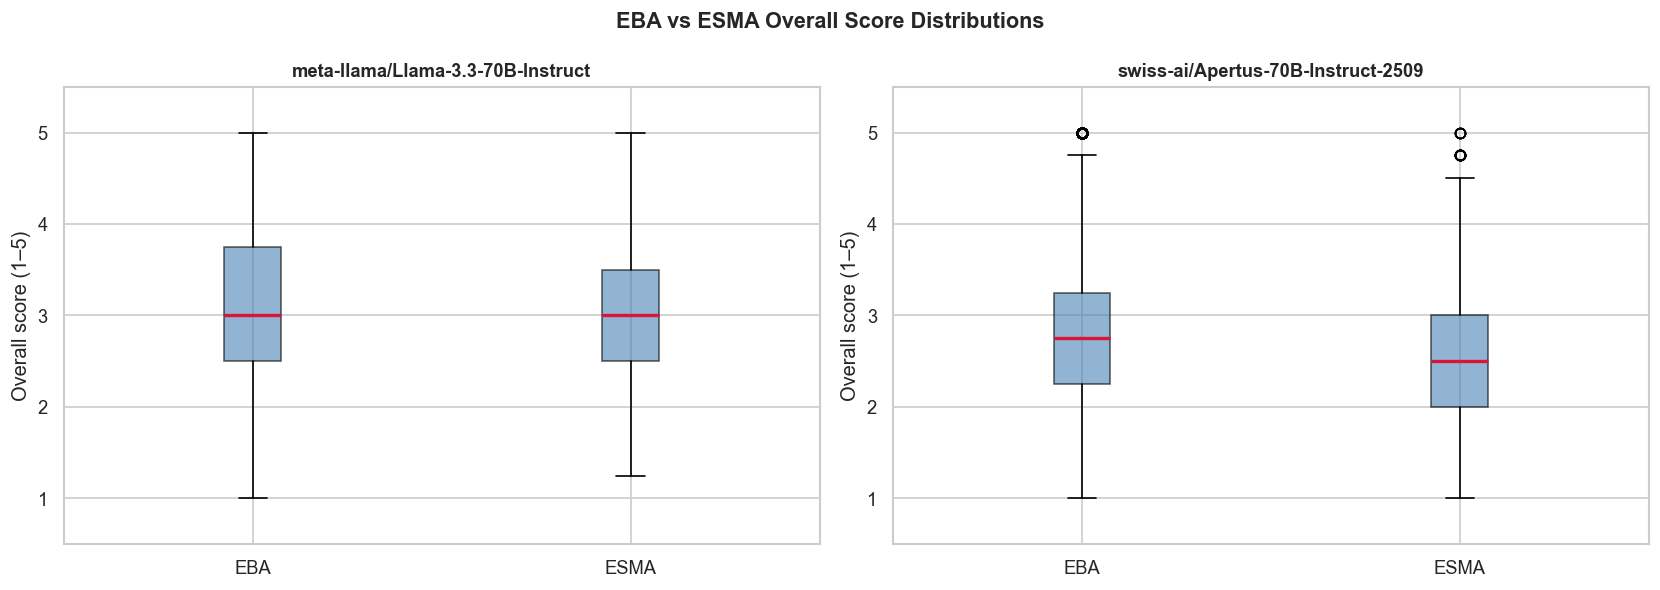

median    Q1    Q3  mean
regulator answerer_model                                              
EBA       meta-llama/Llama-3.3-70B-Instruct     3.00  2.50  3.75  3.14
          swiss-ai/Apertus-70B-Instruct-2509    2.75  2.25  3.25  2.88
ESMA      meta-llama/Llama-3.3-70B-Instruct     3.00  2.50  3.50  3.00
          swiss-ai/Apertus-70B-Instruct-2509    2.50  2.00  3.00  2.60

In [10]:
# Box plots: EBA vs ESMA, per answerer model
fig, axes = plt.subplots(1, len(ANSWERERS), figsize=(7 * len(ANSWERERS), 5))

for ax, answerer in zip(axes, ANSWERERS):
    plot_data = {
        regulator: df.loc[(df["regulator"] == regulator) & (df["answerer_model"] == answerer), "overall"].dropna().values
        for regulator in sorted(df["regulator"].unique())
    }
    ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="crimson", linewidth=2))
    ax.set_ylabel("Overall score (1–5)")
    ax.set_title(answerer, fontsize=11, fontweight="bold")
    ax.set_ylim(0.5, 5.5)

plt.suptitle("EBA vs ESMA Overall Score Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Median / IQR table
reg_stats = []
for regulator in sorted(df["regulator"].unique()):
    for answerer in ANSWERERS:
        d = df.loc[(df["regulator"] == regulator) & (df["answerer_model"] == answerer), "overall"].dropna()
        reg_stats.append({
            "regulator": regulator, "answerer_model": answerer,
            "median": d.median(), "Q1": d.quantile(0.25), "Q3": d.quantile(0.75), "mean": d.mean(),
        })
pd.DataFrame(reg_stats).set_index(["regulator", "answerer_model"]).round(2)

## 6 · Breakdown by Legal Act and Topic

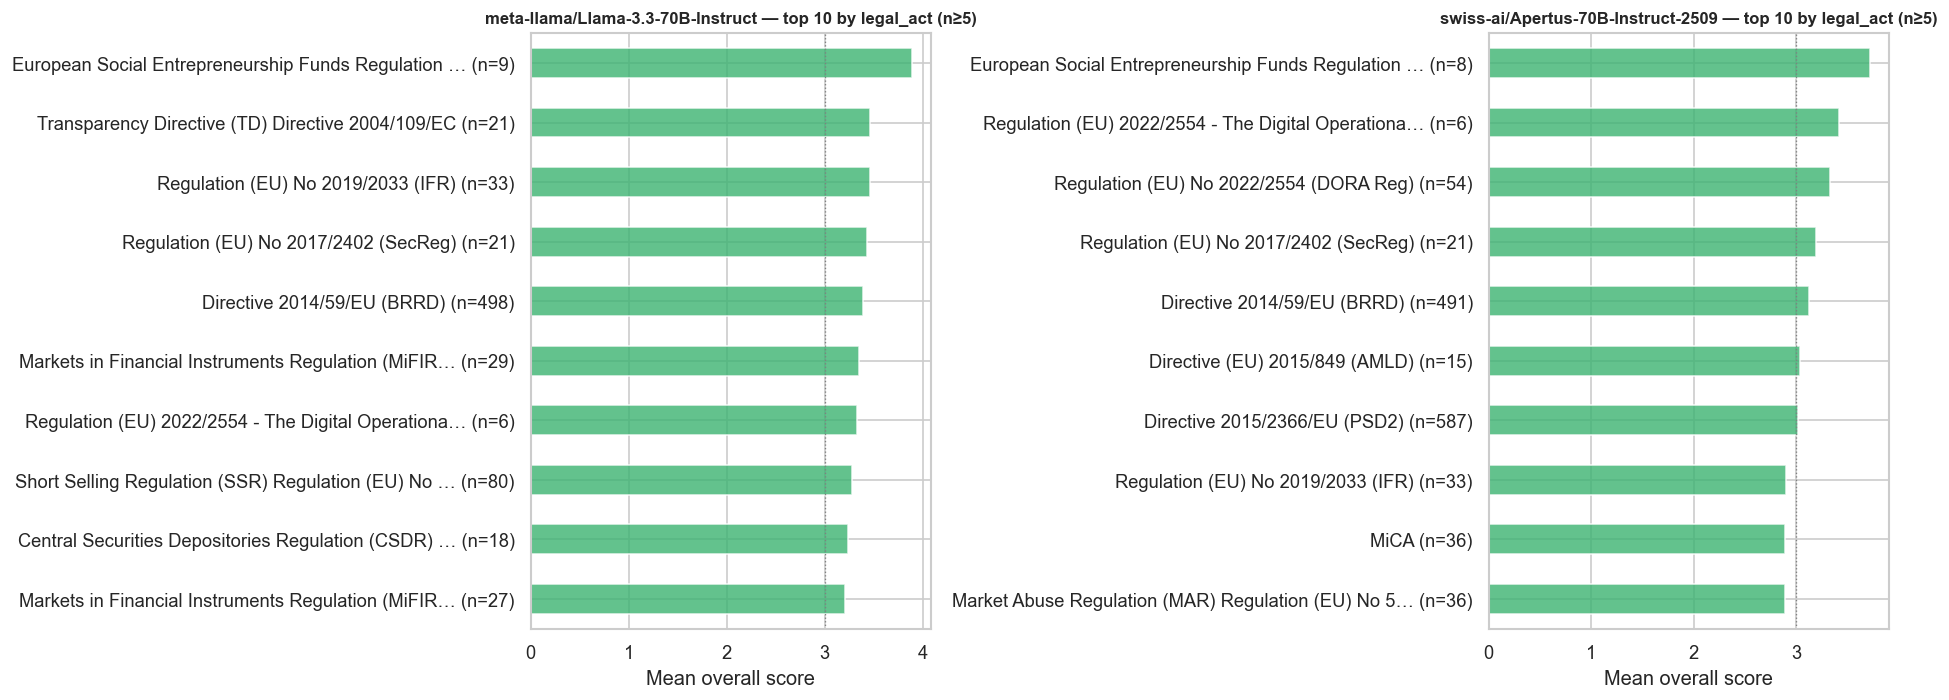

In [11]:
def shorten(s, n=45):
    return s[:n] + "…" if isinstance(s, str) and len(s) > n else s


def top_group_plot(group_col, top_n=10, min_n=5):
    fig, axes = plt.subplots(1, len(ANSWERERS), figsize=(8 * len(ANSWERERS), 6))
    for ax, answerer in zip(axes, ANSWERERS):
        sub = df[df["answerer_model"] == answerer]
        counts = sub[group_col].value_counts()
        valid_groups = counts[counts >= min_n].index
        top = (sub[sub[group_col].isin(valid_groups)]
               .groupby(group_col)["overall"].mean()
               .dropna().sort_values(ascending=False).head(top_n))
        labels = [f"{shorten(g, 50)} (n={counts[g]})" for g in top.index]
        top.index = labels
        top.plot.barh(ax=ax, color="mediumseagreen", alpha=0.8)
        ax.axvline(3, color="grey", linestyle=":", linewidth=0.8)
        ax.set_xlabel("Mean overall score")
        ax.set_title(f"{answerer} — top {top_n} by {group_col} (n≥{min_n})", fontsize=10, fontweight="bold")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


top_group_plot("legal_act")

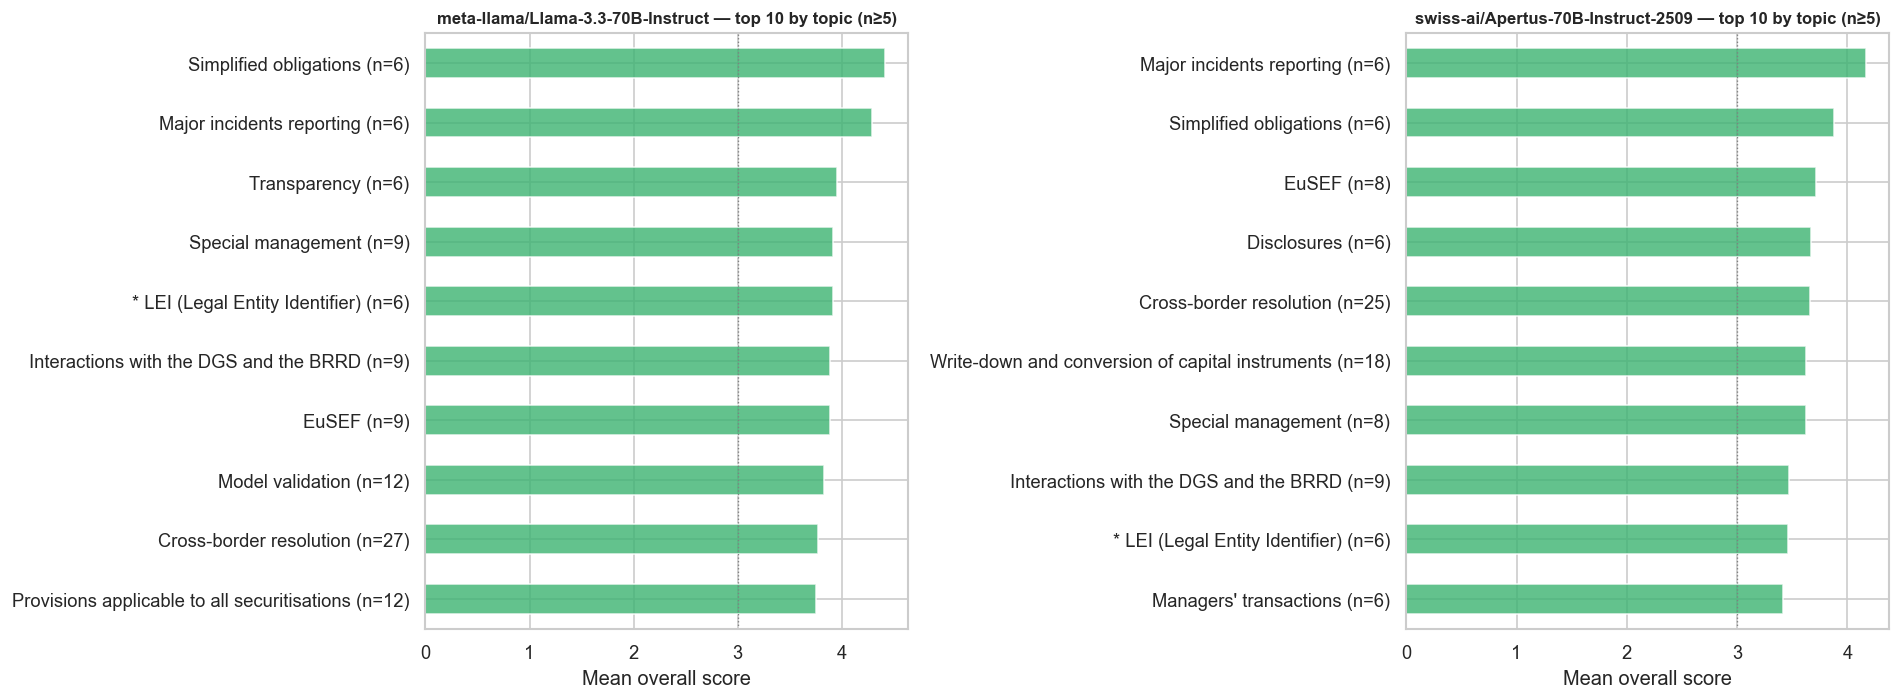

In [12]:
top_group_plot("topic")

## 7 · Dimension Correlations

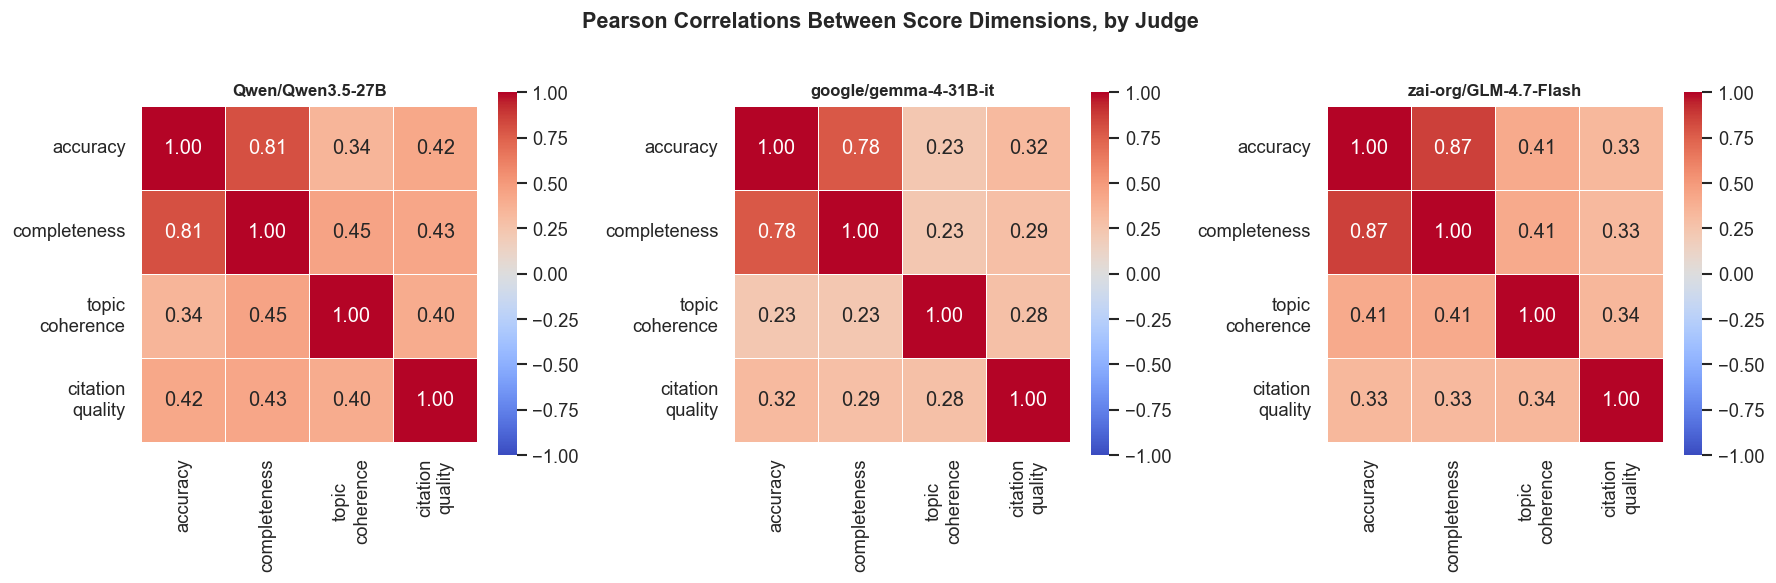

In [13]:
# Pearson correlation heatmap across the 4 score dimensions, one panel per judge
fig, axes = plt.subplots(1, len(JUDGES), figsize=(5 * len(JUDGES), 4.5))

for ax, judge in zip(axes, JUDGES):
    corr = df.loc[df["judge_model"] == judge, DIMS].dropna().corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                linewidths=0.5, square=True,
                xticklabels=[d.replace("_", "\n") for d in DIMS],
                yticklabels=[d.replace("_", "\n") for d in DIMS])
    ax.set_title(judge, fontsize=10, fontweight="bold")

plt.suptitle("Pearson Correlations Between Score Dimensions, by Judge", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8 · Missing Score Analysis

In [14]:
# Missingness in the RAW data (before the complete-case filter applied at load time) —
# shows which judge/dimension/legal-act combinations were dropped.
miss_by_judge = (
    df_raw.groupby("judge_model")[DIMS]
          .apply(lambda g: g.isna().mean() * 100)
)
print("Missing (%) per dimension, by judge model (raw, pre-filter):")
print(miss_by_judge.round(1))
print()

missing = df_raw[df_raw["overall"].isna()]
print(f"Rows dropped for having ≥1 missing dimension: {len(missing)} / {len(df_raw)} "
      f"({len(missing) / len(df_raw) * 100:.2f}%)\n")

print("By judge model:")
print(missing["judge_model"].value_counts())
print()
print("By answerer model:")
print(missing["answerer_model"].value_counts())
print()
print("By regulator:")
print(missing["regulator"].value_counts())
print()
print("Top legal acts with missing scores:")
for la, cnt in missing["legal_act"].value_counts().head(5).items():
    print(f"  {shorten(la, 60):62s}  {cnt}")

Missing (%) per dimension, by judge model (raw, pre-filter):
                       accuracy  completeness  topic_coherence  \
judge_model                                                      
Qwen/Qwen3.5-27B            0.0           0.0              0.0   
google/gemma-4-31B-it       0.0           0.0              0.0   
zai-org/GLM-4.7-Flash       2.2           2.2              2.2   

                       citation_quality  
judge_model                              
Qwen/Qwen3.5-27B                    0.0  
google/gemma-4-31B-it               0.0  
zai-org/GLM-4.7-Flash               2.2  

Rows dropped for having ≥1 missing dimension: 93 / 12828 (0.72%)

By judge model:
judge_model
zai-org/GLM-4.7-Flash    93
Name: count, dtype: int64

By answerer model:
answerer_model
swiss-ai/Apertus-70B-Instruct-2509    54
meta-llama/Llama-3.3-70B-Instruct     39
Name: count, dtype: int64

By regulator:
regulator
EBA     77
ESMA    16
Name: count, dtype: int64

Top legal acts with missing scor

## 9 · Example Answers at Score Extremes

In [15]:
def show_example(sub_df, label, target_score, n=2, seed=42):
    subset = sub_df.dropna(subset=["overall"])
    subset = subset[subset["overall"].round() == target_score]
    sample = subset.sample(min(n, len(subset)), random_state=seed)
    print(f"\n{'='*80}")
    print(f"  {label}  |  overall ≈ {target_score}  ({len(subset)} matching records)")
    print(f"{'='*80}")
    for _, row in sample.iterrows():
        print(f"\n[ID: {row['question_id']}]  answerer={row['answerer_model']}  judge={row['judge_model']}")
        print(f"QUESTION    : {row['question'][:300]}{'...' if len(row['question']) > 300 else ''}")
        print(f"GROUND TRUTH: {row['ground_truth'][:300]}{'...' if len(row['ground_truth']) > 300 else ''}")
        print(f"CANDIDATE   : {row['candidate_answer'][:300]}{'...' if len(row['candidate_answer']) > 300 else ''}")
        print(f"SCORES      : acc={row['accuracy']}  comp={row['completeness']}  "
              f"topic={row['topic_coherence']}  citation={row['citation_quality']}  overall={row['overall']}")
        print(f"REASONING   : {row['reasoning']}")
        print()


show_example(df, "All judgments", target_score=5)
show_example(df, "All judgments", target_score=1)


  All judgments  |  overall ≈ 5  (602 matching records)

[ID: EBA_2017_3486]  answerer=meta-llama/Llama-3.3-70B-Instruct  judge=zai-org/GLM-4.7-Flash
QUESTION    : Template F 20.04, row 210 reports ”Non-financial corporations – Of which: Loans collateralized by commercial immovable property”. However, in Hong Kong there could be non-financial corporations (NFC) borrowing loans that are collateralized solely by ”Residential immovable property” rather than by “C...
GROUND TRUTH: Instructions for rows 210 and 230 of template F 20.04 are given in paragraphs 86(a) and 87, Annex V, Part 2 of Commission Implementing Regulation (EU) No 680/2014. These rows are reported as “of which” in the template.
As such, loans and advances to non-financial corporations that are not collateral...
CANDIDATE   : According to [Regulation (EU) No 575/2013, Art. 415], institutions are required to submit financial reports in accordance with the implementing technical standards. For FINREP Template F 20.04, [Comm

## 10 · Biggest Inter-judge Disagreements

In [16]:
# For each (question, answerer), compute the spread of "overall" across the 3 judges
spread = (
    df.dropna(subset=["overall"])
      .groupby(["question_id", "answerer_model"])["overall"]
      .agg(judge_spread=lambda s: s.max() - s.min(), n_judges="count")
      .reset_index()
)
spread = spread[spread["n_judges"] == len(JUDGES)]  # only cases all judges scored

top_disagreements = spread.nlargest(5, "judge_spread")

cols = ["question", "ground_truth", "candidate_answer"] + DIMS + ["overall", "judge_model", "reasoning"]
for _, d in top_disagreements.iterrows():
    rows = df[(df["question_id"] == d["question_id"]) & (df["answerer_model"] == d["answerer_model"])]
    print(f"\n{'='*90}")
    print(f"  [{d['question_id']}]  answerer={d['answerer_model']}  judge_spread={d['judge_spread']:.1f}")
    print(f"{'='*90}")
    print(f"QUESTION: {rows.iloc[0]['question'][:300]}")
    print(f"GROUND TRUTH: {rows.iloc[0]['ground_truth'][:300]}")
    print(f"CANDIDATE: {rows.iloc[0]['candidate_answer'][:300]}")
    for _, row in rows.iterrows():
        print(f"\n  judge={row['judge_model']}  acc={row['accuracy']}  comp={row['completeness']}  "
              f"topic={row['topic_coherence']}  citation={row['citation_quality']}  overall={row['overall']}")
        print(f"  reasoning: {row['reasoning']}")
    print(f"\n{'-'*90}")


  [ESMA_ESMA_QA_1580]  answerer=swiss-ai/Apertus-70B-Instruct-2509  judge_spread=3.8
QUESTION: a)	Can systematic internalisers meet their quoting obligations under Article 18(1) of MiFIR for liquid instruments by providing executable quotes on a continuous basis?
b)	Can client orders routed by an automated order router (AOR) system be considered as ‘prompting for a quote’ according to Article
GROUND TRUTH: This question was deleted on 16/10/2024.
CANDIDATE: a) According to Article 18(1) of MiFIR, systematic internalisers must provide firm quotes on a continuous basis for liquid instruments. This means that they must provide executable quotes at all times. [Regulation (EU) No 600/2014, Art. 18(1)]

b) Article 18(1)(a) of MiFIR requires that quotes must 

  judge=google/gemma-4-31B-it  acc=5.0  comp=5.0  topic=5.0  citation=4.0  overall=4.75
  reasoning: {'accuracy': 'The official answer is empty as the question was deleted, making factual verification against a ground truth impossible.

In [17]:
# Some ground truths are just a stub like "This question was deleted on 16/10/2024." —
# there's no real reference answer for the judges to compare against, so we'd expect
# these to drive some of the biggest inter-judge disagreements.
deleted_mask = df["ground_truth"].str.strip().str.match(r"^This question was deleted", na=False)
deleted_qids = df.loc[deleted_mask, "question_id"].unique()

print(f"Questions with a 'deleted' ground truth stub: {len(deleted_qids)}")
print(list(deleted_qids))
print()

deleted_spread = spread[spread["question_id"].isin(deleted_qids)]
print(f"Judge-spread stats for these {len(deleted_spread)} (question, answerer) pairs:")
print(deleted_spread["judge_spread"].describe())
print()

rank = spread.sort_values("judge_spread", ascending=False).reset_index(drop=True)
rank["rank"] = rank.index + 1
deleted_ranks = rank[rank["question_id"].isin(deleted_qids)]
print(f"Their rank within all {len(rank)} (question, answerer) pairs by judge_spread "
      f"(1 = biggest disagreement):")
print(deleted_ranks[["rank", "question_id", "answerer_model", "judge_spread"]])

# Show the actual scores judges gave for one of these deleted-question cases
example_qid = deleted_qids[0]
df[df["question_id"] == example_qid][
    ["answerer_model", "judge_model", "candidate_answer"] + DIMS + ["overall"]
]

Questions with a 'deleted' ground truth stub: 4
['ESMA_ESMA_QA_1580', 'ESMA_ESMA_QA_1589', 'ESMA_ESMA_QA_1668', 'ESMA_ESMA_QA_1569']

Judge-spread stats for these 8 (question, answerer) pairs:
count    8.000000
mean     2.937500
std      0.546907
min      2.000000
25%      2.687500
50%      3.000000
75%      3.250000
max      3.750000
Name: judge_spread, dtype: float64

Their rank within all 4183 (question, answerer) pairs by judge_spread (1 = biggest disagreement):
     rank        question_id                      answerer_model  judge_spread
0       1  ESMA_ESMA_QA_1580  swiss-ai/Apertus-70B-Instruct-2509          3.75
2       3  ESMA_ESMA_QA_1580   meta-llama/Llama-3.3-70B-Instruct          3.25
4       5  ESMA_ESMA_QA_1668   meta-llama/Llama-3.3-70B-Instruct          3.25
6       7  ESMA_ESMA_QA_1589  swiss-ai/Apertus-70B-Instruct-2509          3.25
20     21  ESMA_ESMA_QA_1569  swiss-ai/Apertus-70B-Instruct-2509          2.75
21     22  ESMA_ESMA_QA_1668  swiss-ai/Apertus-70B-Inst

,answerer_model,judge_model,candidate_answer,accuracy,completeness,topic_coherence,citation_quality,overall
3805,swiss-ai/Apertus-70B-Instruct-2509,google/gemma-4-31B-it,"a) According to Article 18(1) of MiFIR, system...",5.0,5.0,5.0,4.0,4.75
3806,swiss-ai/Apertus-70B-Instruct-2509,Qwen/Qwen3.5-27B,"a) According to Article 18(1) of MiFIR, system...",1.0,1.0,3.0,1.0,1.50
3807,swiss-ai/Apertus-70B-Instruct-2509,zai-org/GLM-4.7-Flash,"a) According to Article 18(1) of MiFIR, system...",1.0,1.0,1.0,1.0,1.00
3808,meta-llama/Llama-3.3-70B-Instruct,google/gemma-4-31B-it,a) Systematic internalisers can meet their quo...,5.0,5.0,5.0,5.0,5.00
3809,meta-llama/Llama-3.3-70B-Instruct,Qwen/Qwen3.5-27B,a) Systematic internalisers can meet their quo...,1.0,1.0,3.0,2.0,1.75
3810,meta-llama/Llama-3.3-70B-Instruct,zai-org/GLM-4.7-Flash,a) Systematic internalisers can meet their quo...,1.0,1.0,5.0,5.0,3.00
